# Understanding the data

In [704]:
# installing and importing necessary moddules

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


In [705]:
# import data as dataframe

df_train = pd.read_csv(f"/Users/SeanKelly1/Desktop/Projects/Business Intelligence/Tanza/pumpitup_train_data.csv")
df_label = pd.read_csv(f"/Users/SeanKelly1/Desktop/Projects/Business Intelligence/Tanza/pumpitup_label.csv")



df = pd.merge(df_train, df_label, how='inner', on='id',)


In [706]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55765 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59400 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [707]:
for i in df.columns:
    print(i)
    print(df[i].value_counts(normalize=True, dropna=False))

id
69572    0.000017
27851    0.000017
6924     0.000017
61097    0.000017
48517    0.000017
           ...   
59036    0.000017
56446    0.000017
3855     0.000017
52786    0.000017
26348    0.000017
Name: id, Length: 59400, dtype: float64
amount_tsh
0.0         0.700993
500.0       0.052222
50.0        0.041616
1000.0      0.025051
20.0        0.024630
              ...   
6300.0      0.000017
120000.0    0.000017
138000.0    0.000017
350000.0    0.000017
59.0        0.000017
Name: amount_tsh, Length: 98, dtype: float64
date_recorded
2011-03-15    0.009630
2011-03-17    0.009394
2013-02-03    0.009192
2011-03-14    0.008754
2011-03-16    0.008636
                ...   
2011-09-11    0.000017
2011-08-31    0.000017
2011-09-21    0.000017
2011-08-30    0.000017
2013-12-01    0.000017
Name: date_recorded, Length: 356, dtype: float64
funder
Government Of Tanzania    0.152929
NaN                       0.061195
Danida                    0.052424
Hesawa                    0.037071
Rwssp    

In [708]:
df.groupby(["basin"])["population"].aggregate("sum")

basin
Internal                   1302893
Lake Nyasa                  298210
Lake Rukwa                  401505
Lake Tanganyika            1686835
Lake Victoria              1340080
Pangani                    1541900
Rufiji                     1358328
Ruvuma / Southern Coast    1231952
Wami / Ruvu                1524950
Name: population, dtype: int64

## Data Cleaning

In [709]:
df.duplicated().sum()

0

In [710]:
df.shape

(59400, 41)

In [711]:
df.isna().sum()


id                           0
amount_tsh                   0
date_recorded                0
funder                    3635
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     0
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3877
scheme_name              28166
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_

In [712]:
# object features
# 
obj_cols = list(df.select_dtypes('O').columns)
obj_cols

['date_recorded',
 'funder',
 'installer',
 'wpt_name',
 'basin',
 'subvillage',
 'region',
 'lga',
 'ward',
 'public_meeting',
 'recorded_by',
 'scheme_management',
 'scheme_name',
 'permit',
 'extraction_type',
 'extraction_type_group',
 'extraction_type_class',
 'management',
 'management_group',
 'payment',
 'payment_type',
 'water_quality',
 'quality_group',
 'quantity',
 'quantity_group',
 'source',
 'source_type',
 'source_class',
 'waterpoint_type',
 'waterpoint_type_group',
 'status_group']

In [713]:
int_cols = list(df.select_dtypes(exclude=['O']).columns)
int_cols

['id',
 'amount_tsh',
 'gps_height',
 'longitude',
 'latitude',
 'num_private',
 'region_code',
 'district_code',
 'population',
 'construction_year']

In [714]:
col_with_null = ["funder", "scheme_management", "scheme_name", "permit", "public_meeting", "subvillage", "installer"]   

for i in col_with_null:
    temp = len(df[i].unique())
    print(i, temp)

funder 1898
scheme_management 13
scheme_name 2697
permit 3
public_meeting 3
subvillage 19288
installer 2146


This shows that most of the columns with empty responses are objects. 
Hence we further our analysis by categorizing which is binary or cartegorical.

permit binary
public meeting binary
scheme mgt is categorical

for this analysis other columns with nan beyond 13 makes the task complex. Hence we neglect them.
 

We only note the missing value columns as they will be replaced with a constant using sklearn simple_imputer.
 

In [715]:
df.drop(["installer", "subvillage", "scheme_name", "funder"], axis=1, inplace=True)

## Preprocessing

We can now move to univariate analysis to evaluate the importance of each column

In [716]:
temp_dict = {}
for i in col_with_null:
    if i in int_cols:
        temp_dict[i] = "numeric"
    elif i in obj_cols:
        temp_dict[i] = "objects"
temp_dict

{'funder': 'objects',
 'scheme_management': 'objects',
 'scheme_name': 'objects',
 'permit': 'objects',
 'public_meeting': 'objects',
 'subvillage': 'objects',
 'installer': 'objects'}

In [717]:
df.columns

Index(['id', 'amount_tsh', 'date_recorded', 'gps_height', 'longitude',
       'latitude', 'wpt_name', 'num_private', 'basin', 'region', 'region_code',
       'district_code', 'lga', 'ward', 'population', 'public_meeting',
       'recorded_by', 'scheme_management', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='object')

In [718]:
# df["date_recorded"].head() # A new column for the number of years it has lasted this is calculated against the construction year
df["recorded_year"] = df["basin"]
for idx in range(df["date_recorded"].shape[0]):
    df["recorded_year"][idx] = ((df["date_recorded"][idx].split("-")[0]))


/var/folders/t2/rh2ytx5n7y7bmrqmps0gr9yr0000gp/T/ipykernel_16702/1694182668.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["recorded_year"][idx] = ((df["date_recorded"][idx].split("-")[0]))


In [719]:
df["construction_year"] = df["construction_year"].astype("int32")
df["recorded_year"] = df["recorded_year"].astype("int32")


In [720]:
df["well_age"] = df["recorded_year"] - df["construction_year"]

In [721]:
df["construction_year"].head()

0    1999
1    2010
2    2009
3    1986
4       0
Name: construction_year, dtype: int32

In [722]:
a = 0
for i in range(df["well_age"].shape[0]):
    if df["well_age"][i] == df["recorded_year"][i]:
        df["well_age"][i] = np.nan
        a += 1
print(a)

/var/folders/t2/rh2ytx5n7y7bmrqmps0gr9yr0000gp/T/ipykernel_16702/3966445424.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["well_age"][i] = np.nan


20709


It was observed that the some 20709 rows had 0 filled in for construction year. This makes the operation age undeterministic. Because theses value are about 405 of the data.
One way is to make the column categorical. 

We also observe that some 9 rows in the compute well age contains negative value, it is easier to drop them

In [723]:
# df = df[df['well_age'].notna()]
# df.shape

In [724]:
df.drop([])

,id,amount_tsh,date_recorded,gps_height,longitude,latitude,wpt_name,num_private,basin,region,...,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group,recorded_year,well_age
0,69572,6000.0,2011-03-14,1390,34.938093,-9.856322,none,0,Lake Nyasa,Iringa,...,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional,2011,12.0
1,8776,0.0,2013-03-06,1399,34.698766,-2.147466,Zahanati,0,Lake Victoria,Mara,...,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,2013,3.0
2,34310,25.0,2013-02-25,686,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Manyara,...,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional,2013,4.0
3,67743,0.0,2013-01-28,263,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mtwara,...,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional,2013,27.0
4,19728,0.0,2011-07-13,0,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kagera,...,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,2011,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,60739,10.0,2013-05-03,1210,37.169807,-3.253847,Area Three Namba 27,0,Pangani,Kilimanjaro,...,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional,2013,14.0
59396,27263,4700.0,2011-05-07,1212,35.249991,-9.070629,Kwa Yahona Kuvala,0,Rufiji,Iringa,...,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,functional,2011,15.0
59397,37057,0.0,2011-04-11,0,34.017087,-8.750434,Mashine,0,Rufiji,Mbeya,...,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,functional,2011,NaN
59398,31282,0.0,2011-03-08,0,35.861315,-6.378573,Mshoro,0,Rufiji,Dodoma,...,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,functional,2011,NaN


In [725]:
df["status_group"].value_counts() 

for i in df["status_group"].index:
    if df["status_group"][i] == "functional needs repair":
        df["status_group"][i] = "non functional"

df["status_group"].value_counts() 

# Hence we have a balanced label which is required by the models which we will be using 55% F and 45% NF

/var/folders/t2/rh2ytx5n7y7bmrqmps0gr9yr0000gp/T/ipykernel_16702/2459344573.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["status_group"][i] = "non functional"


functional        32259
non functional    27141
Name: status_group, dtype: int64

In [726]:
df["status_group"] = df["status_group"].map({"functional": 1, "non functional": 0})

/var/folders/t2/rh2ytx5n7y7bmrqmps0gr9yr0000gp/T/ipykernel_16702/1657474126.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  seaborn.distplot(a=df["status_group"], color='green',


Text(0.5, 1.0, 'Increased status group variation')

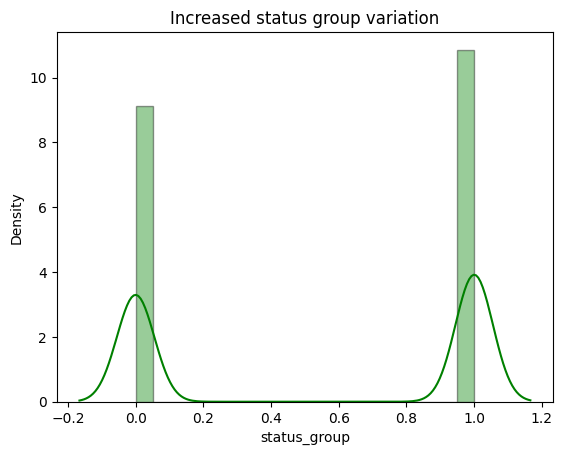

In [727]:
import seaborn
seaborn.distplot(a=df["status_group"], color='green',
             hist_kws={"edgecolor": 'black'})

plt.title("Increased status group variation")

In [728]:
df.drop(["id", "date_recorded"], axis= 1, inplace=True)

In [729]:
df["amount_tsh"].head()
df["amount_tsh"].describe()

# It is observed tha there is high variation with the data, but since we would be scaling it. we can move on.

count     59400.000000
mean        317.650385
std        2997.574558
min           0.000000
25%           0.000000
50%           0.000000
75%          20.000000
max      350000.000000
Name: amount_tsh, dtype: float64

In [730]:
df["gps_height"].describe() # The same process appliable to amount_tsh can be applied to gps_height

count    59400.000000
mean       668.297239
std        693.116350
min        -90.000000
25%          0.000000
50%        369.000000
75%       1319.250000
max       2770.000000
Name: gps_height, dtype: float64

In [731]:
df["basin"].unique()

array(['Lake Nyasa', 'Lake Victoria', 'Pangani',
       'Ruvuma / Southern Coast', 'Internal', 'Lake Tanganyika',
       'Wami / Ruvu', 'Rufiji', 'Lake Rukwa'], dtype=object)

In [732]:
# Basin lat lon 

basin_loc = {
            'Lake Nyasa':{"lat": -11.670115, "lon": 34.685651},
            'Lake Victoria': {"lat": -1.00000, "lon": 33.000000}, 
            'Pangani': {"lat": -5.42526, "lon": 38.97473},
            'Ruvuma / Southern Coast': {"lat": -11.000, "lon": 36.0000}, 
            'Lake Tanganyika': {"lat": -6.50000000, "lon": 29.8333332}, 
            'Rufiji': {"lat": -8.008698, "lon": 38.987674},
            'Wami / Ruvu': {"lat": -6.1333, "lon": 38.8167},
            'Internal': {"lat": 0.000000, "lon": 0.000000}, 
            'Lake Rukwa': {"lat": -8.000000, "lon": 32.416665}
            }

In [733]:
basin_loc["Internal"]["lat"]

0.0

In [734]:
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance in kilometers between two points 
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    return c * r

In [735]:
# From the lon and lat we can calculate the proximity of the well from the regional center
df["dist_to_basin"] = 0
for i in df.index:
    if df["basin"][i] in basin_loc:
        basin_lat = basin_loc[df["basin"][i]]["lat"]
        basin_lon = basin_loc[df["basin"][i]]["lon"]
        well_lat = df["latitude"][i]
        well_lon = df["longitude"][i]
        # print(basin_lat, basin_lon, well_lat, well_lon)
        df["dist_to_basin"][i] = haversine(well_lon, well_lat, basin_lon, basin_lat)

/var/folders/t2/rh2ytx5n7y7bmrqmps0gr9yr0000gp/T/ipykernel_16702/1859796352.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["dist_to_basin"][i] = haversine(well_lon, well_lat, basin_lon, basin_lat)


In [736]:
df["dist_to_basin"].head()

0    203.560969
1    227.887496
2    244.880019
3    271.845743
4    227.141791
Name: dist_to_basin, dtype: float64

In [737]:
df.drop(["longitude", "latitude"], axis=1, inplace=True)

In [738]:
# The water point name can be dropped as no uniqueness can be traced
len(df["wpt_name"].unique())
df.drop(["wpt_name"], axis=1, inplace=True)

In [739]:
# Num private: we do not know its representation as of now 
df['num_private'].head()
df['num_private'].unique()

array([   0,   39,    5,   45,    6,    3,  698,   32,   15,    7,   25,
        102,    1,   93,   14,   34,  120,   17,  213,   47,    8,   41,
         80,  141,   20,   35,  131,    4,   22,   11,   87,   61,   65,
        136,    2,  180,   38,   62,    9,   16,   23,   42,   24,   12,
        668,  672,   58,  150,  280,  160,   50, 1776,   30,   27,   10,
         94,   26,  450,  240,  755,   60,  111,  300,   55, 1402])

In [740]:
df["basin"].unique()

array(['Lake Nyasa', 'Lake Victoria', 'Pangani',
       'Ruvuma / Southern Coast', 'Internal', 'Lake Tanganyika',
       'Wami / Ruvu', 'Rufiji', 'Lake Rukwa'], dtype=object)

In [741]:
df["region"].unique()

array(['Iringa', 'Mara', 'Manyara', 'Mtwara', 'Kagera', 'Tanga',
       'Shinyanga', 'Tabora', 'Pwani', 'Ruvuma', 'Kilimanjaro', 'Rukwa',
       'Mwanza', 'Kigoma', 'Lindi', 'Dodoma', 'Arusha', 'Mbeya',
       'Singida', 'Morogoro', 'Dar es Salaam'], dtype=object)

In [742]:
df["region_code"].unique()
df["region_code"].map({11:"11", 20:"20", 21:"21", 90:"91",  4:"4", 10:"10",  3:"3", 15:"15", 19:"19", 16:"16", 80:"80",  6:"6",  2:"2", 13:"13",  5:"5", 18:"18",  7:"7",
                            99:"99", 24:"24",  9:"9", 60:"60", 17:"17",  8:"8", 40:"40"})
df["region_code"] = df["region_code"].astype(str)

In [743]:
df["region_code"][0]

'11'

In [744]:
df["district_code"].unique()
df["district_code"].unique()
df["district_code"] = df["district_code"].astype(str)


In [745]:
df["lga"].unique()

array(['Ludewa', 'Serengeti', 'Simanjiro', 'Nanyumbu', 'Karagwe',
       'Mkinga', 'Shinyanga Rural', 'Kahama', 'Tabora Urban', 'Mkuranga',
       'Namtumbo', 'Maswa', 'Siha', 'Meatu', 'Sumbawanga Rural', 'Njombe',
       'Ukerewe', 'Bariadi', 'Same', 'Kigoma Rural', 'Moshi Rural',
       'Lindi Rural', 'Rombo', 'Chamwino', 'Bagamoyo', 'Mafia',
       'Arusha Rural', 'Kyela', 'Kondoa', 'Kilolo', 'Kibondo', 'Makete',
       'Singida Rural', 'Masasi', 'Rungwe', 'Moshi Urban', 'Geita',
       'Mbulu', 'Bukoba Rural', 'Muheza', 'Lushoto', 'Meru', 'Iramba',
       'Kilombero', 'Mbarali', 'Kasulu', 'Bukoba Urban', 'Korogwe',
       'Bukombe', 'Morogoro Rural', 'Kishapu', 'Musoma Rural',
       'Sengerema', 'Iringa Rural', 'Muleba', 'Dodoma Urban', 'Ruangwa',
       'Hanang', 'Misenyi', 'Missungwi', 'Songea Rural', 'Tanga',
       'Tunduru', 'Hai', 'Mwanga', 'Chato', 'Biharamulo', 'Ileje',
       'Mpwapwa', 'Mvomero', 'Bunda', 'Kiteto', 'Longido', 'Urambo',
       'Mbozi', 'Sikonge', 'Ilala',

In [746]:
len(df["ward"].unique())

2092

In [747]:
len(df["population"].unique())

1049

In [748]:
df["public_meeting"].unique()
df["public_meeting"].isna().sum()
df["public_meeting"].value_counts(normalize=True, dropna=False)

True     0.858771
False    0.085101
NaN      0.056128
Name: public_meeting, dtype: float64

In [749]:
df["recorded_by"].unique() # No variance hence we drop it
df.drop(["recorded_by"], axis=1, inplace= True)


In [750]:
df["scheme_management"].unique()

array(['VWC', 'Other', nan, 'Private operator', 'WUG', 'Water Board',
       'WUA', 'Water authority', 'Company', 'Parastatal', 'Trust', 'SWC',
       'None'], dtype=object)

In [751]:
df["permit"].unique()
df["permit"].value_counts(normalize=True, dropna=False)

True     0.654074
False    0.294478
NaN      0.051448
Name: permit, dtype: float64

In [752]:
# df["construction_year"].unique()
# df["construction_year"].astype("category")
# df["construction_year"].value_counts()
df.drop(["construction_year"], axis=1, inplace= True)

In [753]:
df["extraction_type"].unique()

array(['gravity', 'submersible', 'swn 80', 'nira/tanira', 'india mark ii',
       'other', 'ksb', 'mono', 'windmill', 'afridev', 'other - rope pump',
       'india mark iii', 'other - swn 81', 'other - play pump', 'cemo',
       'climax', 'walimi', 'other - mkulima/shinyanga'], dtype=object)

In [754]:
df["extraction_type_group"].unique()

array(['gravity', 'submersible', 'swn 80', 'nira/tanira', 'india mark ii',
       'other', 'mono', 'wind-powered', 'afridev', 'rope pump',
       'india mark iii', 'other handpump', 'other motorpump'],
      dtype=object)

In [755]:
df["extraction_type_class"].unique()

array(['gravity', 'submersible', 'handpump', 'other', 'motorpump',
       'wind-powered', 'rope pump'], dtype=object)

In [756]:
df["management"].unique()

array(['vwc', 'wug', 'other', 'private operator', 'water board', 'wua',
       'company', 'water authority', 'parastatal', 'unknown',
       'other - school', 'trust'], dtype=object)

In [757]:
df["management_group"].unique()

array(['user-group', 'other', 'commercial', 'parastatal', 'unknown'],
      dtype=object)

In [758]:
df["payment"].unique()

array(['pay annually', 'never pay', 'pay per bucket', 'unknown',
       'pay when scheme fails', 'other', 'pay monthly'], dtype=object)

In [759]:
df["payment_type"].unique()

array(['annually', 'never pay', 'per bucket', 'unknown', 'on failure',
       'other', 'monthly'], dtype=object)

In [760]:
df["water_quality"].unique()


array(['soft', 'salty', 'milky', 'unknown', 'fluoride', 'coloured',
       'salty abandoned', 'fluoride abandoned'], dtype=object)

In [761]:
df["quality_group"].unique()

array(['good', 'salty', 'milky', 'unknown', 'fluoride', 'colored'],
      dtype=object)

In [762]:
df["quantity"].unique()

array(['enough', 'insufficient', 'dry', 'seasonal', 'unknown'],
      dtype=object)

In [763]:
df["quantity_group"].unique()

array(['enough', 'insufficient', 'dry', 'seasonal', 'unknown'],
      dtype=object)

In [764]:
df["source"].unique()

array(['spring', 'rainwater harvesting', 'dam', 'machine dbh', 'other',
       'shallow well', 'river', 'hand dtw', 'lake', 'unknown'],
      dtype=object)

In [765]:
df["source_type"].unique()

array(['spring', 'rainwater harvesting', 'dam', 'borehole', 'other',
       'shallow well', 'river/lake'], dtype=object)

In [766]:
df["source_class"].unique()

array(['groundwater', 'surface', 'unknown'], dtype=object)

In [767]:
df["waterpoint_type"].unique()

array(['communal standpipe', 'communal standpipe multiple', 'hand pump',
       'other', 'improved spring', 'cattle trough', 'dam'], dtype=object)

In [768]:
df["waterpoint_type_group"].unique()

array(['communal standpipe', 'hand pump', 'other', 'improved spring',
       'cattle trough', 'dam'], dtype=object)

In [769]:
df["status_group"].unique()

array([1, 0])

In [770]:
df["recorded_year"].unique()
df["recorded_year"].astype("category")


0        2011
1        2013
2        2013
3        2013
4        2011
         ... 
59395    2013
59396    2011
59397    2011
59398    2011
59399    2011
Name: recorded_year, Length: 59400, dtype: category
Categories (5, int64): [2002, 2004, 2011, 2012, 2013]

In [771]:
df["well_age"].unique()


array([12.,  3.,  4., 27., nan,  2.,  0., 26., 20., 33., 19., 39., 13.,
       11.,  7., 41.,  8.,  5., 25.,  9., 38., 28., 43.,  1., 16., 22.,
       10., 24.,  6., 35., 49., 14., 15., 37., 17., 36., 30., 51., 23.,
       29., 53., 50., 31., 21., 42., 18., 45., 34., 46., 40., 44., 32.,
       48., 47., 52., -4., -2., -7., -5., -1., -3.])

In [772]:
df["dist_to_basin"].unique()


array([203.56096875, 227.88749642, 244.88001891, ..., 552.98122516,
       389.6179112 , 104.23154001])

In [773]:
for i in df.select_dtypes("O").columns:
    print(i)
    print("-"*len(i))
    a = df[i].value_counts(dropna=False)
    print(a)
    print()
    
    

basin
-----
Lake Victoria              10248
Pangani                     8940
Rufiji                      7976
Internal                    7785
Lake Tanganyika             6432
Wami / Ruvu                 5987
Lake Nyasa                  5085
Ruvuma / Southern Coast     4493
Lake Rukwa                  2454
Name: basin, dtype: int64

region
------
Iringa           5294
Shinyanga        4982
Mbeya            4639
Kilimanjaro      4379
Morogoro         4006
Arusha           3350
Kagera           3316
Mwanza           3102
Kigoma           2816
Ruvuma           2640
Pwani            2635
Tanga            2547
Dodoma           2201
Singida          2093
Mara             1969
Tabora           1959
Rukwa            1808
Mtwara           1730
Manyara          1583
Lindi            1546
Dar es Salaam     805
Name: region, dtype: int64

region_code
-----------
11    5300
17    5011
12    4639
3     4379
5     4040
18    3324
19    3047
2     3024
16    2816
10    2640
4     2513
1     2201
13  

In [774]:
len(df.columns)

33

True     0.858771
False    0.085101
NaN      0.056128
Name: public_meeting, dtype: float64


/var/folders/t2/rh2ytx5n7y7bmrqmps0gr9yr0000gp/T/ipykernel_16702/3413416469.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  seaborn.distplot(a=a, color='green',


Text(0.5, 1.0, 'public_meeting plot')

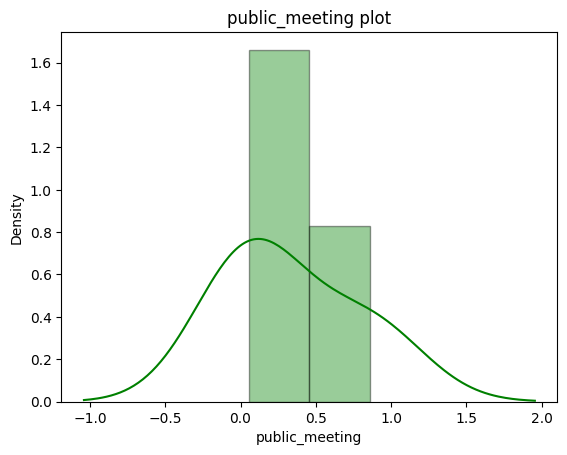

In [775]:
i = "public_meeting"
df[i].astype("category")
a = df[i].value_counts(normalize=True, dropna=False)
print(a)
seaborn.distplot(a=a, color='green',
             hist_kws={"edgecolor": 'black'})

plt.title(f"{i} plot")




 0       0.344074
-15      0.001010
-16      0.000926
-13      0.000926
 1290    0.000875
           ...   
 2378    0.000017
-54      0.000017
 2057    0.000017
 2332    0.000017
 2366    0.000017
Name: gps_height, Length: 2428, dtype: float64


/var/folders/t2/rh2ytx5n7y7bmrqmps0gr9yr0000gp/T/ipykernel_16702/495826401.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  seaborn.distplot(a=a, color='green',


Text(0.5, 1.0, 'gps_height plot')

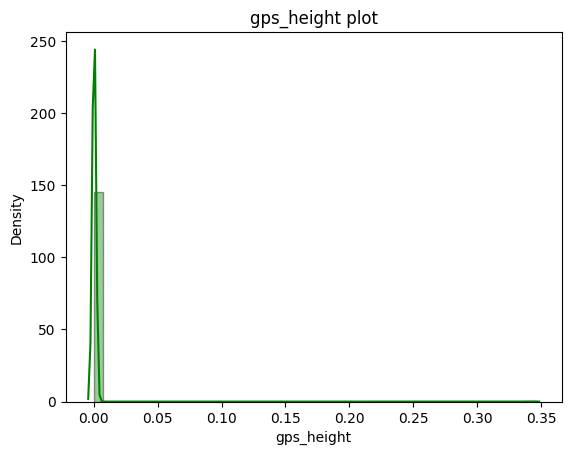

In [776]:
i = "gps_height"
a = df[i].value_counts(normalize=True, dropna=False)
print(a)
seaborn.distplot(a=a, color='green',
             hist_kws={"edgecolor": 'black'})

plt.title(f"{i} plot")




VWC                 0.619411
WUG                 0.087643
NaN                 0.065269
Water authority     0.053081
WUA                 0.048535
Water Board         0.046263
Parastatal          0.028283
Private operator    0.017896
Company             0.017862
Other               0.012896
SWC                 0.001633
Trust               0.001212
None                0.000017
Name: scheme_management, dtype: float64


/var/folders/t2/rh2ytx5n7y7bmrqmps0gr9yr0000gp/T/ipykernel_16702/3221551469.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  seaborn.distplot(a=a, color='green',


Text(0.5, 1.0, 'scheme_management plot')

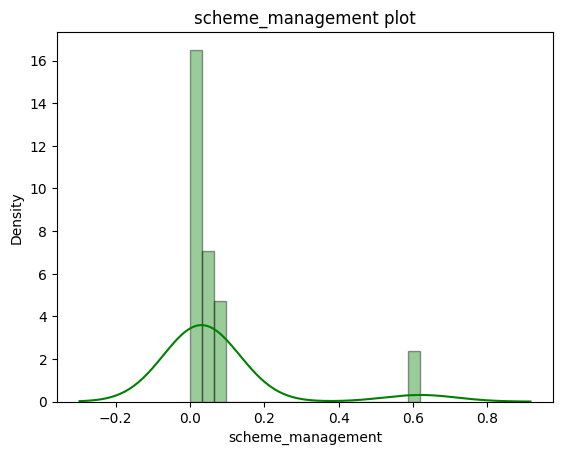

In [777]:

i = "scheme_management"
a = df[i].value_counts(normalize=True, dropna=False)
print(a)
seaborn.distplot(a=a, color='green',
             hist_kws={"edgecolor": 'black'})

plt.title(f"{i} plot")




# Test Train split

In [778]:
df.isna().sum()

amount_tsh                   0
gps_height                   0
num_private                  0
basin                        0
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
scheme_management         3877
permit                    3056
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_group                0
quantity                     0
quantity_group               0
source                       0
source_type                  0
source_class                 0
waterpoint_type              0
waterpoint_type_group        0
status_group                 0
recorded_year                0
well_age                 20709
dist_to_

In [779]:

df = df.dropna()
# df["scheme_management"].fillna("null", inplace=True)

In [780]:
df.isna().sum()

amount_tsh               0
gps_height               0
num_private              0
basin                    0
region                   0
region_code              0
district_code            0
lga                      0
ward                     0
population               0
public_meeting           0
scheme_management        0
permit                   0
extraction_type          0
extraction_type_group    0
extraction_type_class    0
management               0
management_group         0
payment                  0
payment_type             0
water_quality            0
quality_group            0
quantity                 0
quantity_group           0
source                   0
source_type              0
source_class             0
waterpoint_type          0
waterpoint_type_group    0
status_group             0
recorded_year            0
well_age                 0
dist_to_basin            0
dtype: int64

In [781]:
df.shape

(32515, 33)

In [782]:

df["permit"] = df["permit"].astype(float)
df["permit"] = df["permit"].astype(str)
df["public_meeting"] = df["public_meeting"].astype(float)
df["public_meeting"] = df["public_meeting"].astype(str)
df["recorded_year"] = df["recorded_year"].astype(str)

In [783]:
df["recorded_year"].unique()

array(['2011', '2013', '2012', '2004'], dtype=object)

In [784]:
df["permit"].unique()

array(['0.0', '1.0'], dtype=object)

In [785]:
Y = df["status_group"]
X = df.drop(["status_group"], axis=1)
X.columns

Index(['amount_tsh', 'gps_height', 'num_private', 'basin', 'region',
       'region_code', 'district_code', 'lga', 'ward', 'population',
       'public_meeting', 'scheme_management', 'permit', 'extraction_type',
       'extraction_type_group', 'extraction_type_class', 'management',
       'management_group', 'payment', 'payment_type', 'water_quality',
       'quality_group', 'quantity', 'quantity_group', 'source', 'source_type',
       'source_class', 'waterpoint_type', 'waterpoint_type_group',
       'recorded_year', 'well_age', 'dist_to_basin'],
      dtype='object')

In [786]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=0.2, random_state=869)

print(X_tr.shape, X_te.shape, y_tr.shape, y_te.shape)

(26012, 32) (6503, 32) (26012,) (6503,)


We then create a pipeline  for our transformer 

In [787]:
## import function needed for split
from sklearn.model_selection import train_test_split

## import classes necessary for building preprocessing pipelines
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

int_cols = list(X.select_dtypes(exclude="O"))
obj_cols = list(X.select_dtypes(include="O"))
stand_scaler = Pipeline(steps=[("normalize", StandardScaler())])
cat_processor = Pipeline(steps=[
                            ("impute_null", SimpleImputer(strategy="constant", fill_value= "null")), 
                            ("encode", OneHotEncoder(drop="if_binary", handle_unknown = "ignore")) 
                                ])

col_transformer = ColumnTransformer(transformers=[("numbers", stand_scaler, int_cols),
                                                   ("category", cat_processor, obj_cols)])

In [788]:
for i in X_tr.columns:
    print(X_tr[i].unique)

<bound method Series.unique of 54323    1000.0
47973       0.0
6130     3000.0
58265    1000.0
47936      20.0
          ...  
18489    7200.0
45288     500.0
49281       0.0
34735       0.0
11266    2000.0
Name: amount_tsh, Length: 26012, dtype: float64>
<bound method Series.unique of 54323    1425
47973    1570
6130     1948
58265     987
47936     225
         ... 
18489    1791
45288    1715
49281    1790
34735     934
11266     970
Name: gps_height, Length: 26012, dtype: int64>
<bound method Series.unique of 54323    0
47973    0
6130     0
58265    0
47936    0
        ..
18489    0
45288    0
49281    0
34735    0
11266    0
Name: num_private, Length: 26012, dtype: int64>
<bound method Series.unique of 54323                   Internal
47973                   Internal
6130             Lake Tanganyika
58265                 Lake Nyasa
47936                Wami / Ruvu
                  ...           
18489                   Internal
45288                 Lake Nyasa
49281            

In [789]:
print(y_tr.value_counts(normalize=True))
print(y_te.value_counts(normalize=True)) # Fairly balanced labels

1    0.578272
0    0.421728
Name: status_group, dtype: float64
1    0.564662
0    0.435338
Name: status_group, dtype: float64


In [790]:
X_trr = col_transformer.fit(X_tr)
X_tee = col_transformer.fit_transform(X_te)

In [791]:
# num_df = df.drop(columns=obj_cols, axis=1)
# num_df.hist(figsize=(18, 20), bins='auto')

In [792]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32515 entries, 0 to 59399
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   amount_tsh             32515 non-null  float64
 1   gps_height             32515 non-null  int64  
 2   num_private            32515 non-null  int64  
 3   basin                  32515 non-null  object 
 4   region                 32515 non-null  object 
 5   region_code            32515 non-null  object 
 6   district_code          32515 non-null  object 
 7   lga                    32515 non-null  object 
 8   ward                   32515 non-null  object 
 9   population             32515 non-null  int64  
 10  public_meeting         32515 non-null  object 
 11  scheme_management      32515 non-null  object 
 12  permit                 32515 non-null  object 
 13  extraction_type        32515 non-null  object 
 14  extraction_type_group  32515 non-null  object 
 15  ex

/var/folders/t2/rh2ytx5n7y7bmrqmps0gr9yr0000gp/T/ipykernel_16702/1802082310.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = X.corr().abs()


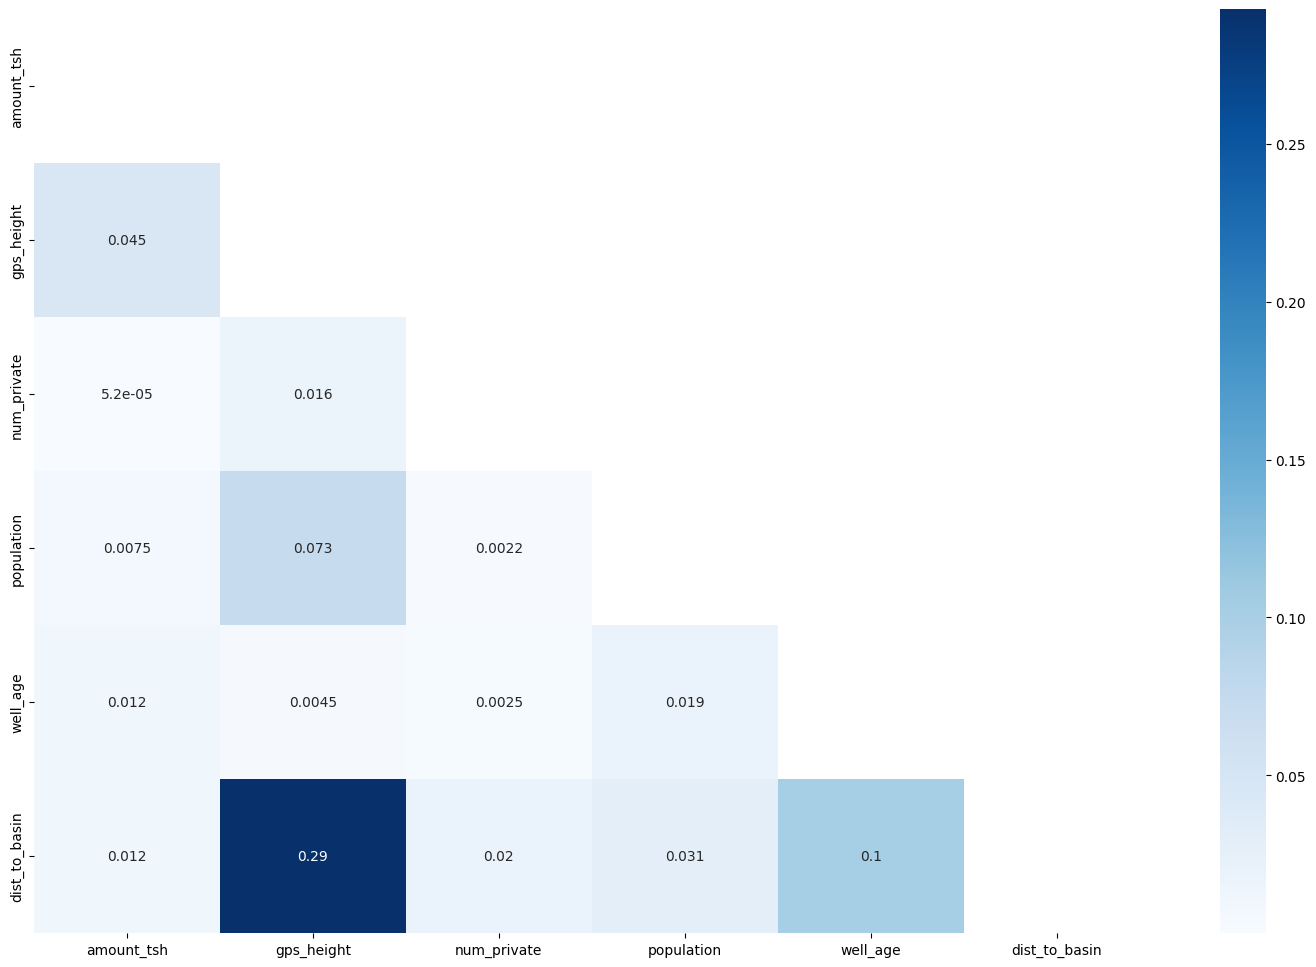

In [793]:
# plot correlations among variables as an annotated heatmap
corr = X.corr().abs()
mask = np.zeros_like(corr)

## mask the correlations of the variables with themselves along the diagonal and all duplicate
## correlations to the right of that line
mask[np.triu_indices_from(mask)] = True
# mask
plt.figure(figsize=(18,12))
seaborn.heatmap(corr, annot=True, cmap='Blues', mask=mask);


In [797]:
# eval_classifier(logisticReg, X_train_trans, y_train, model_descr='Baseline Logistic Regression with Default Params');

def model_metrics(model, X_test, y_test, labels = ['Functional', 'Not_Functional']):


    from sklearn.metrics import classification_report, plot_confusion_matrix, plot_roc_curve, RocCurveDisplay

    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred=y_pred, target_names=labels)

    print(report)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    plot_confusion_matrix(model, X_test, y_test, 
                    display_labels=labels, 
                    normalize="true", cmap="Reds", ax = axes[0])
    plt.title('Confusion Matrix', fontdict={'fontsize': 18,'fontweight': 'bold'})

    plot_roc_curve(model, X_test, y_test, ax=axes[1])
    # plot line that demonstrates probable success when randomly guessing labels
    plt.plot([0,1],[0,1], ls='--', color='r')



In [795]:
from sklearn.linear_model import LogisticRegression
logisticReg = Pipeline(steps=[('preprocess', col_transformer),
                          ('lr', LogisticRegression(solver='sag', random_state=745))])

logisticReg.fit(X_tr, y_tr)


/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numbers',
                                                  Pipeline(steps=[('normalize',
                                                                   StandardScaler())]),
                                                  ['amount_tsh', 'gps_height',
                                                   'num_private', 'population',
                                                   'well_age',
                                                   'dist_to_basin']),
                                                 ('category',
                                                  Pipeline(steps=[('impute_null',
                                                                   SimpleImputer(fill_value='null',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_...
                                                   'permit', 'extraction_type',
                                                   'extraction_type_group',
                                                   'extraction_type_class',
                                                   'management',
                                                   'management_group',
                                                   'payment', 'payment_type',
                                                   'water_quality',
                                                   'quality_group', 'quantity',
                                                   'quantity_group', 'source',
                                                   'source_type',
                                                   'source_class',
                                                   'waterpoint_type',
                                                   'waterpoint_type_group',
                                                   'recorded_year'])])),
                ('lr', LogisticRegression(random_state=745, solver='sag'))])

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [2, 5, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [2, 5, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-pack

                precision    recall  f1-score   support

    Functional       0.81      0.67      0.74      2831
Not_Functional       0.78      0.88      0.83      3672

      accuracy                           0.79      6503
     macro avg       0.80      0.78      0.78      6503
  weighted avg       0.79      0.79      0.79      6503



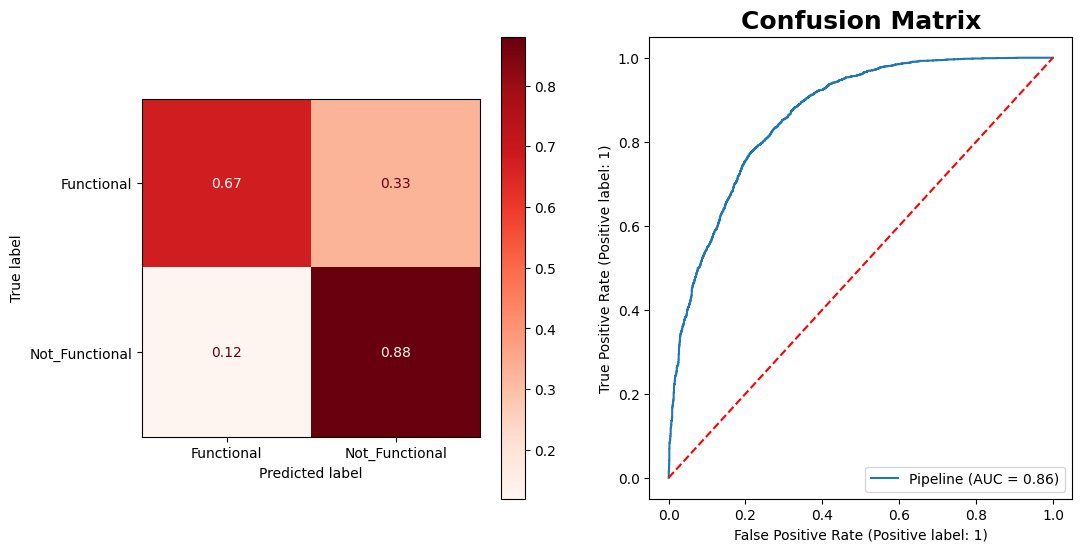

In [798]:

model_metrics(logisticReg, X_te, y_te)

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


There are  1476 features


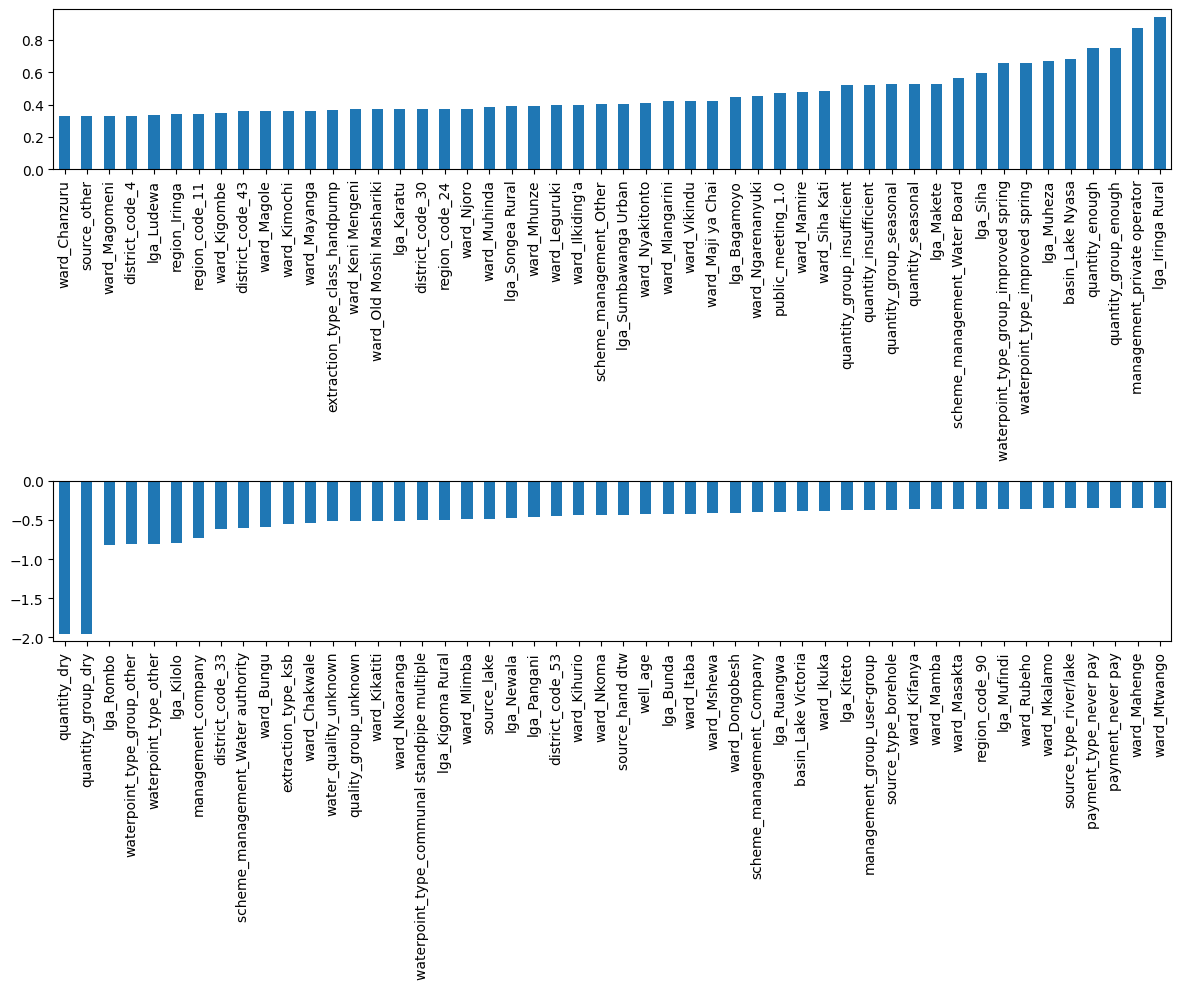

In [799]:
## get the feature names in the order they appear in preprocessed data
feature_names = col_transformer.named_transformers_['category'].named_steps['encode'].get_feature_names(obj_cols)
feature_names = np.r_[int_cols, feature_names]
# feature_names
print("There are ", len(feature_names), "features")

logisticReg_coeff = logisticReg.named_steps["lr"].coef_
sort_lr = logisticReg_coeff.argsort()
importance = pd.Series(logisticReg_coeff[0], index=feature_names)
fig, axes = plt.subplots(2, figsize=(12,10))
importance.sort_values().tail(50).plot(kind='bar', ax=axes[0])
importance.sort_values().head(50).plot(kind='bar', ax=axes[1])
# importance.sort_values().head(60).plot(kind='bar', ax=axes[2])
# importance.sort_values().head(60).plot(kind='bar', ax=axes[3])
# importance.sort_values().head(60).plot(kind='bar', ax=axes[4])
plt.tight_layout()
plt.show()


/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [2, 5, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [2, 5, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


                precision    recall  f1-score   support

    Functional       0.82      0.77      0.80      2831
Not_Functional       0.83      0.87      0.85      3672

      accuracy                           0.83      6503
     macro avg       0.83      0.82      0.82      6503
  weighted avg       0.83      0.83      0.83      6503



/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metrics.RocCurveDisplay.from_predictions` or :meth:`sklearn.metrics.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [2, 5, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


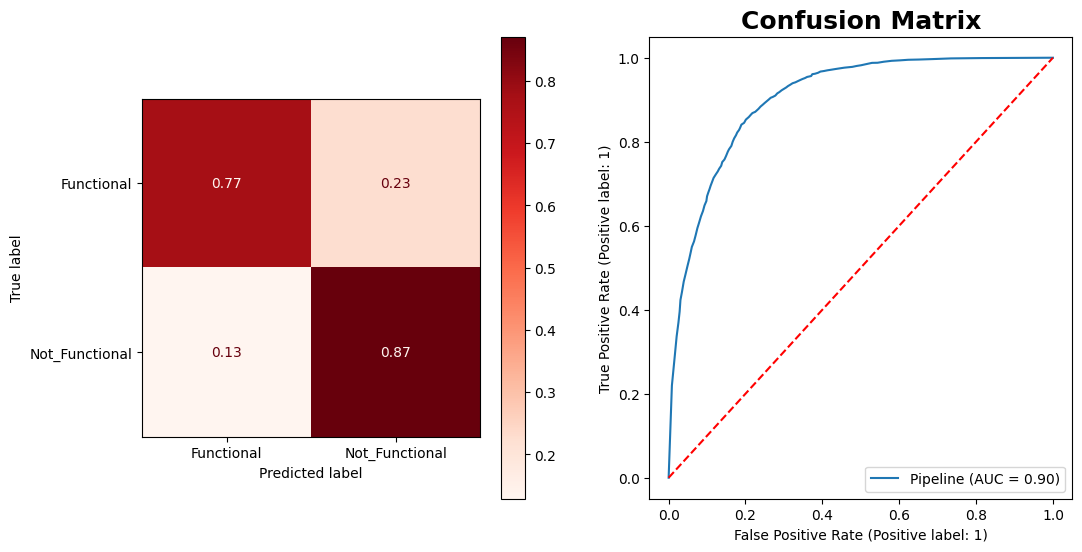

In [686]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

RF_pipe = Pipeline(steps=[("preprocess", col_transformer), ("RF", RandomForestClassifier(n_estimators=100, random_state=456))])

RF = RF_pipe.fit(X_tr, y_tr)

model_metrics(RF, X_te, y_te)

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


There are  1476 features
[0.02415651 0.10435418 0.00203092 ... 0.0030394  0.00069277 0.00276176]
amount_tsh                     0.024157
gps_height                     0.024157
num_private                    0.024157
population                     0.024157
well_age                       0.024157
                                 ...   
waterpoint_type_group_other    0.024157
recorded_year_2004             0.024157
recorded_year_2011             0.024157
recorded_year_2012             0.024157
recorded_year_2013             0.024157
Length: 1476, dtype: float64


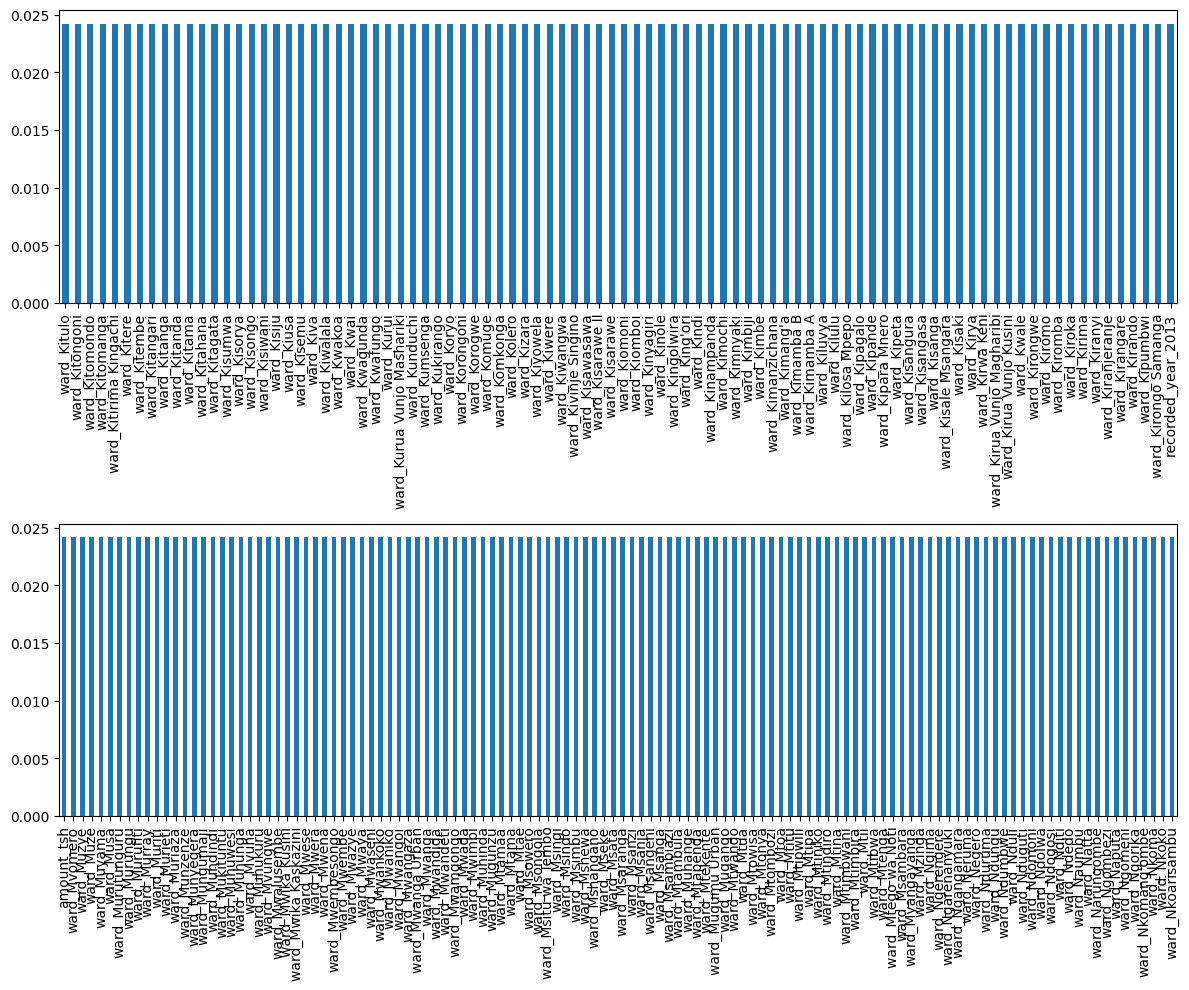

In [691]:
## get the feature names in the order they appear in preprocessed data
feature_names = col_transformer.named_transformers_['category'].named_steps['encode'].get_feature_names(obj_cols)
feature_names = np.r_[int_cols, feature_names]
# feature_names
print("There are ", len(feature_names), "features")

logisticReg_coeff = RF.named_steps["RF"].feature_importances_
print(logisticReg_coeff)
sort_lr = logisticReg_coeff.argsort()
importance = pd.Series(logisticReg_coeff[0], index=feature_names)

print(importance)
fig, axes = plt.subplots(2, figsize=(12,10))
importance.sort_values().tail(90).plot(kind='bar', ax=axes[0])
importance.sort_values().head(120).plot(kind='bar', ax=axes[1])
# importance.sort_values().head(60).plot(kind='bar', ax=axes[2])
# importance.sort_values().head(60).plot(kind='bar', ax=axes[3])
# importance.sort_values().head(60).plot(kind='bar', ax=axes[4])
plt.tight_layout()
plt.show()


In [693]:
from sklearn.metrics import confusion_matrix, accuracy_score,  roc_auc_score as ras
y_pred = RF.predict(X_te)
cm = confusion_matrix(y_te, y_pred)
print(cm)
print(accuracy_score(y_te,y_pred))
ras(y_te, y_pred, average='macro', sample_weight=None, max_fpr=None, multi_class='raise', labels=None)

[[2193  638]
 [ 473 3199]]
0.8291557742580348


/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:188: UserWarning: Found unknown categories in columns [2, 5, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


0.8229126504795568